In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
url = os.environ["DATABASE_URL"].replace("postgresql://", "postgresql+psycopg://")
engine = create_engine(url, pool_pre_ping=True)

In [6]:
df = pd.read_sql("""
    WITH latest AS (
        SELECT DISTINCT ON (listing_id) listing_id, price, currency
        FROM listing_snapshots
        ORDER BY listing_id, captured_at DESC
    )
    SELECT l.neighborhood, s.price, l.covered_m2, l.ambientes, l.bedrooms
    FROM latest s
    JOIN listings l ON l.id = s.listing_id
    WHERE s.currency = 'USD'
      AND l.covered_m2 > 0
      AND s.price IS NOT NULL
""", engine)

df["price_per_m2"] = df["price"] / df["covered_m2"]

In [7]:
df["price_per_m2"].describe()

count    1901.000000
mean     2664.411886
std       897.003818
min       626.050420
25%      2043.181818
50%      2562.500000
75%      3148.818898
max      8000.000000
Name: price_per_m2, dtype: float64

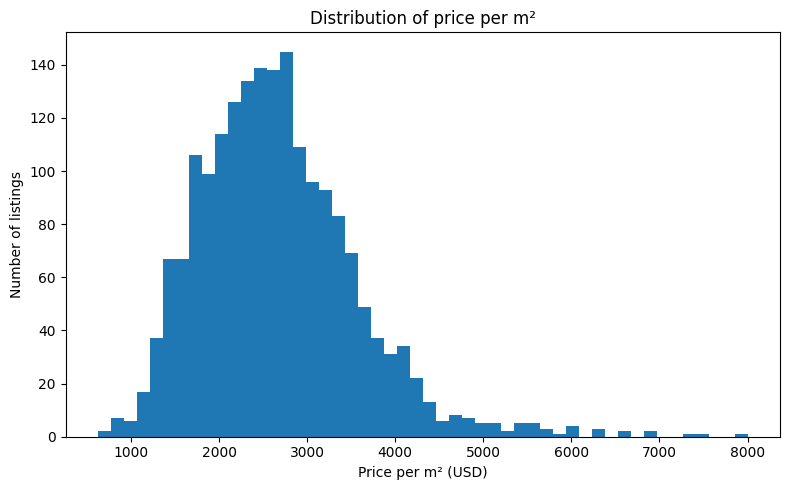

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["price_per_m2"], bins= 50)
ax.set_xlabel("Price per m² (USD)")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of price per m²")
plt.tight_layout()
plt.show()

/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_79783/232842838.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=barrios)


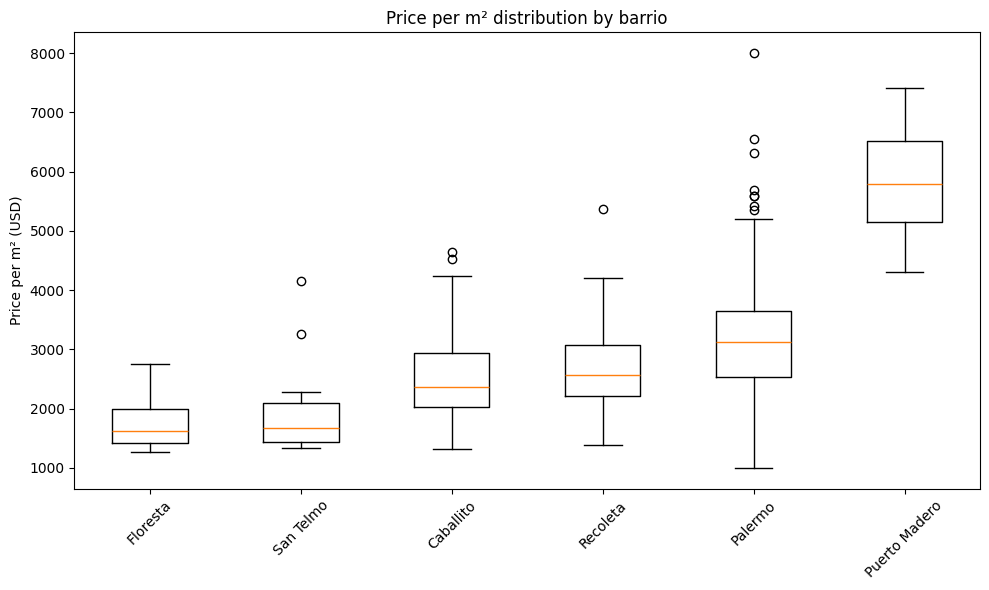

In [14]:
barrios = ["Floresta", "San Telmo", "Caballito", "Recoleta", "Palermo", "Puerto Madero"]
data = [df[df["neighborhood"] == b]["price_per_m2"] for b in barrios]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, labels=barrios)
ax.set_ylabel("Price per m² (USD)")
ax.set_title("Price per m² distribution by barrio")
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig("../report/charts/price_per_m2_spread.png", dpi=150, bbox_inches="tight")
plt.show()